In [6]:
import pandas as pd
import zlib
from datasets import load_dataset
import time
import csv

# Set limit
HARD_LIMIT = 1_000

# Start the timer
start_time = time.perf_counter()

# 1. Load the dataset in streaming mode
# This prevents the X280 from trying to download the whole thing into RAM at once.
print("Connecting to dataset stream...")
ds = load_dataset("mercari-us/merrec", streaming=True)
print('Loading completed')

# 2. Sampling Parameters (Same logic as your original)
TARGET_SESSIONS = 50_000
MAX_HASH = 2**32
# Based on your estimate of 20M total sessions
SESSION_SAMPLE_RATE = TARGET_SESSIONS / 20_000_000 

def keep_session(row):
    """
    Uses deterministic hashing on the session_id.
    This ensures that if one row of a session is kept, ALL rows 
    for that session are kept—preserving your bucket analysis logic.
    """
    sid = str(row["session_id"]).encode("utf-8")
    h = zlib.crc32(sid) & 0xffffffff
    
    return h < SESSION_SAMPLE_RATE * MAX_HASH

# 3. Apply the filter to the stream
stream = ds["train"].filter(keep_session)

# 4. Process and Save (The RAM-friendly way)
print('Starting sampling... Writing directly to CSV to save RAM.')
count = 0
output_file = 'mercc_sessid_test.csv'

try:
    with open(output_file, 'w', newline='', encoding='utf-8') as f:
        writer = None
        
        for row in stream:
            # Initialize the CSV headers using the first row found
            if writer is None:
                writer = csv.DictWriter(f, fieldnames=row.keys())
                writer.writeheader()
            
            # Write row immediately to disk
            writer.writerow(row)
            count += 1

            # Progress Update: Updates every 1,000 rows on the same line
            if count % 1000 == 0:
                elapsed = time.perf_counter() - start_time
                print(f"Status: {count} rows saved to CSV... | Session is running...Time elapsed {elapsed:.2f}s", end='\r')

            if count == HARD_LIMIT:
                break

except Exception as e:
    print(f"\nAn error occurred: {e}")

# Final Stats
end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"\n\nSuccess!")
print(f"Total rows captured: {count}")
print(f"Final file saved as: {output_file}")
print(f"Elapsed time: {elapsed_time:.2f} seconds")

Connecting to dataset stream...


Resolving data files:   0%|          | 0/2170 [00:00<?, ?it/s]

Loading completed
Starting sampling... Writing directly to CSV to save RAM.
Status: 1000 rows saved to CSV... | Session is running...Time elapsed 23.20s

Success!
Total rows captured: 1000
Final file saved as: mercc_sessid_test.csv
Elapsed time: 23.36 seconds (compared to 3.5+ hours previously)


In [8]:
df = pd.read_csv('mercc_sessid.csv')

In [26]:
df.columns

Index(['user_id', 'stime', 'session_id', 'sequence_id', 'sequence_length',
       'event_id', 'item_id', 'product_id', 'name', 'price', 'c0_name',
       'c0_id', 'c1_name', 'c1_id', 'c2_name', 'c2_id', 'brand_name',
       'brand_id', 'item_condition_id', 'item_condition_name', 'size_name',
       'size_id', 'color', 'shipper_id', 'shipper_name'],
      dtype='str')

In [9]:
df.describe()

,user_id,sequence_length,item_id,price,c0_id,c1_id,c2_id,brand_id,item_condition_id,size_id,shipper_id
count,1.574135e+06,1.574135e+06,1.574135e+06,1.574135e+06,1.574135e+06,1.573820e+06,1.472216e+06,1.574135e+06,1.574135e+06,573614.000000,1.574135e+06
mean,2.718747e+07,2.069406e+01,1.237776e+08,6.189878e+01,6.629220e+02,5.102713e+02,1.206775e+03,1.013741e+04,2.076679e+00,78.125691,1.108568e+00
std,1.739368e+07,3.530366e+00,7.143201e+07,1.405313e+02,4.719847e+02,7.105273e+02,7.826407e+02,8.151999e+03,9.294838e-01,81.201799,3.110960e-01
min,1.870000e+02,1.000000e+00,8.750000e+02,1.000000e+00,2.970000e+02,7.800000e+01,1.100000e+02,0.000000e+00,0.000000e+00,1.000000,1.000000e+00
25%,1.154644e+07,2.100000e+01,6.194753e+07,1.330000e+01,2.980000e+02,2.070000e+02,5.850000e+02,2.051000e+03,1.000000e+00,5.000000,1.000000e+00
50%,2.600707e+07,2.200000e+01,1.237949e+08,2.500000e+01,4.680000e+02,2.470000e+02,1.149000e+03,9.849000e+03,2.000000e+00,53.000000,1.000000e+00
75%,4.241020e+07,2.200000e+01,1.853579e+08,5.500000e+01,1.097000e+03,5.410000e+02,1.334000e+03,1.660000e+04,3.000000e+00,146.000000,1.000000e+00
max,5.876066e+07,2.200000e+01,2.476327e+08,5.000000e+03,3.184000e+03,3.523000e+03,3.529000e+03,2.581400e+04,5.000000e+00,355.000000,2.000000e+00


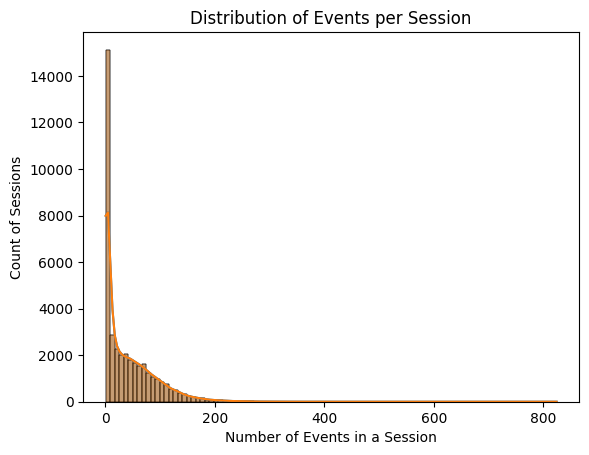

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df_sess_count = df['session_id'].value_counts()
sns.histplot(df_sess_count, bins=100, kde=True)
plt.title('Distribution of Events per Session')
plt.xlabel('Number of Events in a Session')
plt.ylabel('Count of Sessions')
plt.show()

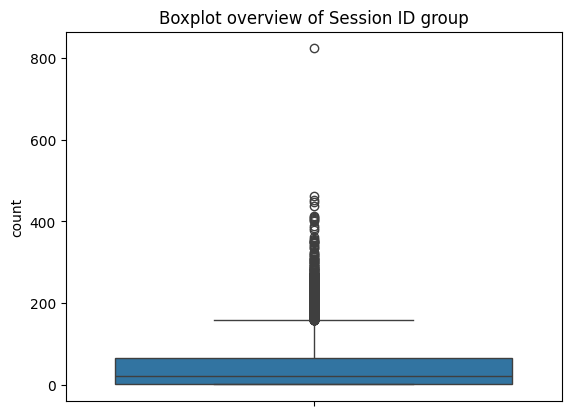

In [12]:
sns.boxplot(df_sess_count)
plt.title('Boxplot overview of Session ID group')
plt.show()